# Plot clustering stability (ARI) of all tested spatial clusterings

In [1]:
import numpy as np
import anndata as ad
import scanpy as sc
import squidpy as sq
from pathlib import Path
import matplotlib.pyplot as plt
import os
import pandas as pd
import cellcharter as cc

/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_tex

In [2]:
cd ../../

/exports/archive/hg-groep-spitali/Students/Caro


/exports/archive/hg-groep-spitali/Students/Caro/conda/envs/cellcharter/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


# Plot clustering stability (spatial graph hop neighborhood)

## Fibers + nuclei clustering (trVAE + GMM/Leiden)

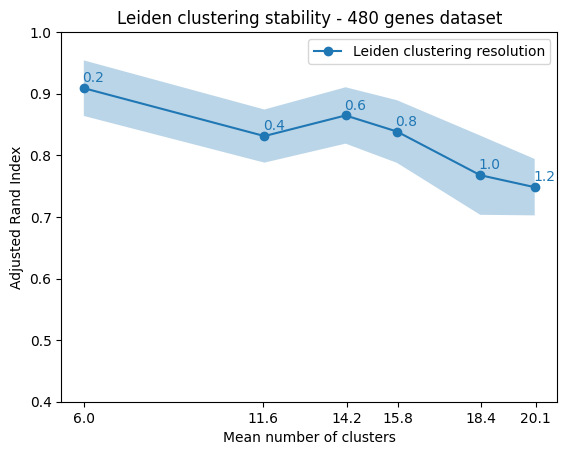

In [ ]:
# 480 leiden
df = pd.read_csv('output/clustering_stability/clustering_stability_480_fibnuc_trVAE_Leiden_30runs.csv')

plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.3, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 480 genes dataset")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

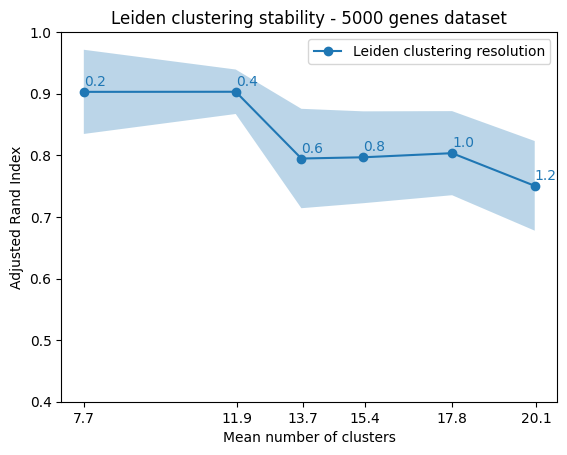

In [5]:
# 5000 leiden
df = pd.read_csv('output/clustering_stability/clustering_stability_5000_fibnuc_trVAE_Leiden_30runs.csv')

plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.3, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 5000 genes dataset")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.savefig('output/clustering_stability/leiden_stability_5000.svg')
plt.show()

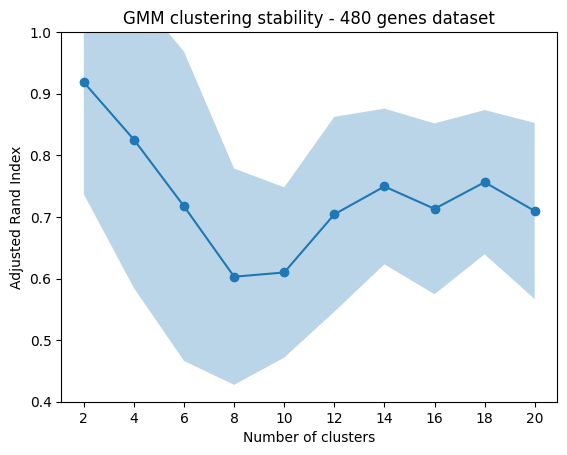

In [ ]:
# 480 GMM
df = pd.read_csv('output/clustering_stability/clustering_stability_480_fibnuc_trVAE_GMM_30runs.csv')

plt.figure()
plt.plot(df["n_clusters"], df["ari_mean"], marker='o')

plt.fill_between(
    df["n_clusters"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

plt.xlabel("Number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("GMM clustering stability - 480 genes dataset")
plt.xticks(round(df["n_clusters"], 1))
plt.ylim(0.4, 1.0)
plt.show()

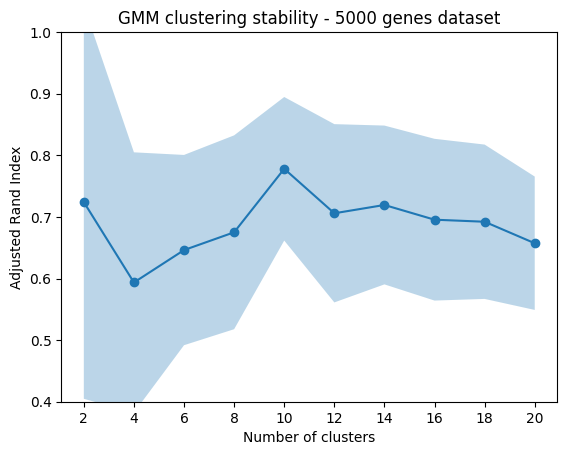

In [6]:
# 5000 GMM
df = pd.read_csv('output/clustering_stability/clustering_stability_5000_fibnuc_trVAE_GMM_30runs.csv')

plt.figure()
plt.plot(df["n_clusters"], df["ari_mean"], marker='o')

plt.fill_between(
    df["n_clusters"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

plt.xlabel("Number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("GMM clustering stability - 5000 genes dataset")
plt.xticks(round(df["n_clusters"], 1))
plt.ylim(0.4, 1.0)
plt.savefig('output/clustering_stability/gmm_stability_5000.svg')
plt.show()

## Only fibers clustering (trVAE + Leiden)

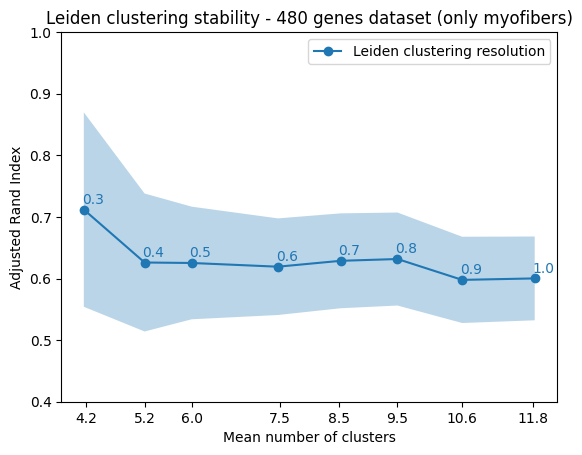

In [ ]:
# 480 leiden
df = pd.read_csv('output/clustering_stability/clustering_stability_leiden_480_fibnuc_fibers_trvae_30runs_clean.csv')


plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.15, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 480 genes dataset (only myofibers)")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

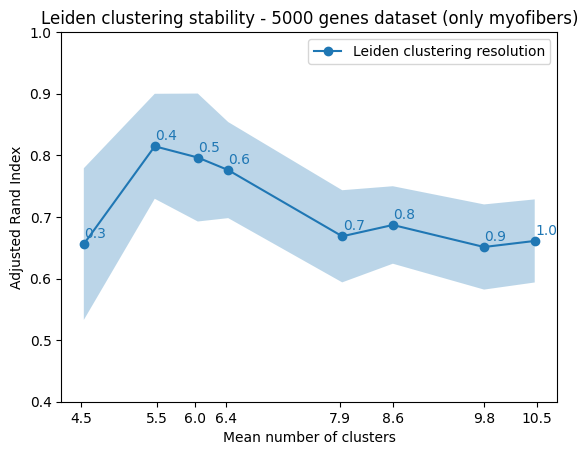

In [ ]:
# 5000 leiden
df = pd.read_csv('output/clustering_stability/clustering_stability_leiden_5000_fibnuc_fibers_trvae_30runs_clean.csv')

plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.15, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 5000 genes dataset (only myofibers)")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

# Plot clustering stability (radius neighborhood)

## Fibers + nuclei clustering (trVAE + Leiden)

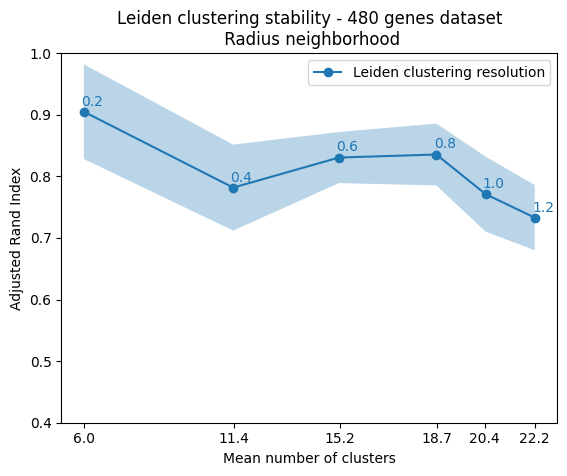

In [ ]:
# 480 leiden - radius neighborhood
df = pd.read_csv('output/clustering_stability/clustering_stability_480_fibnuc_radius_30runs.csv')

plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.3, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 480 genes dataset\nRadius neighborhood")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

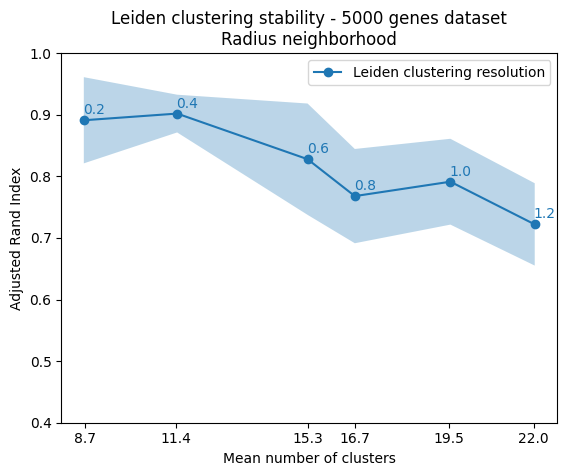

In [18]:
# 5000 leiden - radius neighborhood
df = pd.read_csv('output/clustering_stability/clustering_stability_5000_fibnuc_radius_30runs.csv')

plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.3, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 5000 genes dataset\nRadius neighborhood")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

## Only fibers clustering (trVAE + Leiden)

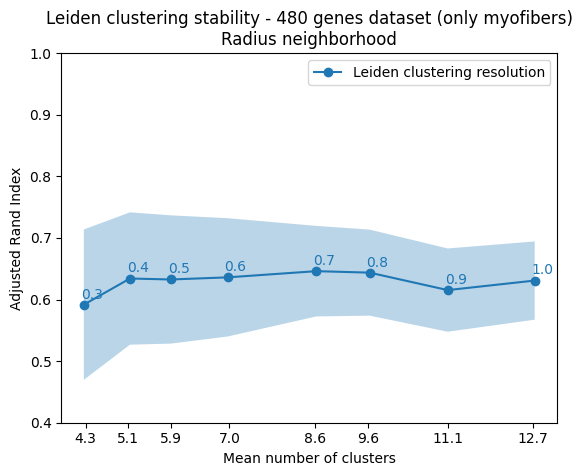

In [20]:
# 480 leiden - Radius neighborhood
df = pd.read_csv('output/clustering_stability/clustering_stability_480_fibnuc_fibers_radius_30runs.csv')


plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.15, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 480 genes dataset (only myofibers)\nRadius neighborhood")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()

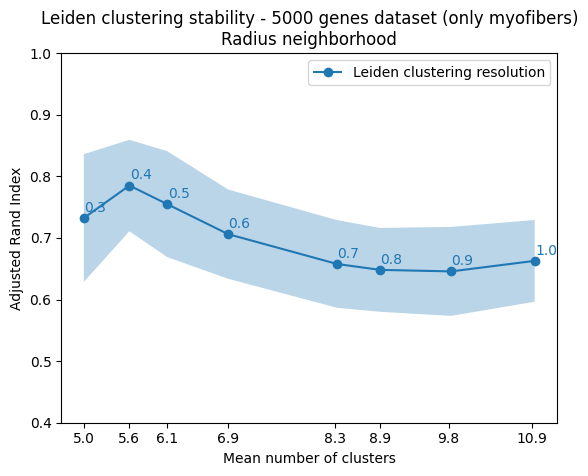

In [21]:
# 480 leiden - Radius neighborhood
df = pd.read_csv('output/clustering_stability/clustering_stability_5000_fibnuc_fibers_radius_30runs.csv')


plt.figure()
plt.plot(df["n_clusters_mean"], df["ari_mean"], marker='o', label='Leiden clustering resolution')

plt.fill_between(
    df["n_clusters_mean"],
    df["ari_mean"] - df["ari_sd"],
    df["ari_mean"] + df["ari_sd"],
    alpha=0.3,
)

# add resolution labels
for x, y, res in zip(df["n_clusters_mean"], df["ari_mean"], df["resolution"]):
    plt.text(x+0.15, y+0.005, f"{res}", ha="center", va="bottom", fontsize=10, color='#1f77b4')

plt.xlabel("Mean number of clusters")
plt.ylabel("Adjusted Rand Index")
plt.title("Leiden clustering stability - 5000 genes dataset (only myofibers)\nRadius neighborhood")
plt.xticks(round(df["n_clusters_mean"], 1))
plt.ylim(0.4, 1.0)
plt.legend()
plt.show()